In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data=pd.read_excel('https://www.robertohincapie.com/data/datos_viviendas1.xlsx')
data.head()

,Cod_Inmueble,Barrio,Precio,Antiguedad,Area_Construida,Area_Privada,Valor_Admon,Parqueaderos,Habitaciones,Baños,Estrato
0,11318-M3058418,Castropol/Poblado,518000000,Entre 0 y 5 años,110.0,122.0,377000.0,1,4,3,6.0
1,11318-M3021864,Belen/Malibu,382000000,Entre 0 y 5 años,64.0,64.0,190000.0,1,2,3,5.0
2,11318-M3058231,Laureles,845000000,Entre 0 y 5 años,137.0,137.0,530000.0,2,3,4,5.0
3,13155-M3070155,EL POBLADO DE SANTA MARIA DE LOS ANGELES,705000000,Entre 0 y 5 años,123.0,123.0,600000.0,2,3,2,6.0
4,2364-M3070004,El Tesoro,1250000000,Remodelado,232.0,232.0,680000.0,2,3,5,6.0


<Axes: >

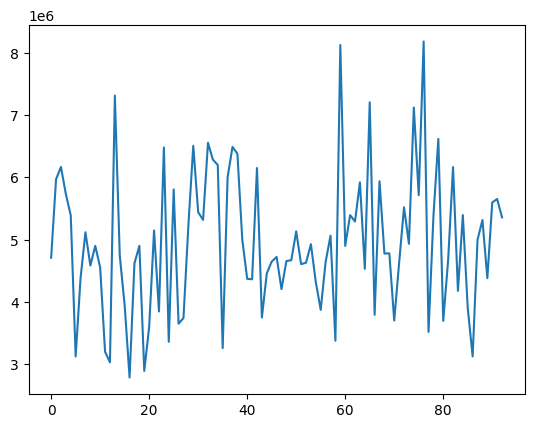

In [ ]:
#Vamos a calcular una nueva columna que tiene el precio por metro cuadrado
data['ValorPorMetroCuadrado']=data['Precio']/data['Area_Construida']
data['ValorPorMetroCuadrado'].plot()

In [ ]:
#Reemplazo de los barrios. Este es en cierta forma un mapeo:
#Cada valor de barrio lo cambiamos por otro de acuerdo con el diccionario que lo define.
data['Barrio']=data['Barrio'].replace({'Castropol/Poblado':'Poblado','Belen/Malibu':'Belén','Laureles':'Laureles','EL POBLADO DE SANTA MARIA DE LOS ANGELES':'Poblado',
'El Tesoro':'Poblado','san Germán':'Robledo','EL TESORO':'Poblado','EL PESEBRE':'Robledo','EL POBLADO':'Poblado','Conquistadores':'Conquistadores',
'LOS BALSOS':'Poblado','La Calera':'Poblado','Calasanz':'Calasanz','BELEN RODEO ALTO':'Belén','El Poblado':'Poblado','Castropol':'Poblado',
'Ciudad Del Río':'Poblado','poblado':'Poblado','La Candelaria':'Centro', 'Loma De Los Bernal':'Belén', 'LA LINDE':'Poblado',
'San Lucas':'Poblado', 'Los Balsos':'Poblado', 'La Pilarica':'Robledo', 'CAMPESTRE':'Poblado', 'Poblado':'Poblado','ALTOS DEL POBLADO':'Poblado',
'lalinde':'Poblado','Balsos':'Poblado', 'LA FLORIDA':'Poblado','LOS BALSOS NO 1':'Poblado', 'Las Palmas':'Poblado', 'Loma del Indio':'Poblado',
'POBLADO LA FRONTERA':'Poblado', 'Conquistadores/occidente':'Conquistadores', 'Los Parra':'Poblado','Belen':'Belén', 'Medellín':'Medellín',
'Los colores':'Los Colores', 'Sabaneta':'Sabaneta','EL POBLADO LA LINDE':'Poblado', 'Los Balsos - El Poblado':'Poblado', 'LA AMERICA':'La América',
'Santa Maria De Los':'Poblado', 'LAURELES':'Laureles'})
data['Barrio'].unique()

array(['Poblado', 'Belén', 'Laureles', 'Robledo', 'Conquistadores',
       'Calasanz', 'Centro', 'Medellín', 'Los Colores', 'Sabaneta',
       'La América'], dtype=object)

In [ ]:
#Convirtamos la columna de antigüedad en un número, para poder graficar el valor por metro cuadrado con respecto a la antigüedad de la propiedad.
data['Antiguedad'].unique()

array(['Entre 0 y 5 años', 'Remodelado', 'Entre 10 y 20 años',
       'Entre 5 y 10 años', 'Más de 20 años'], dtype=object)

<ipython-input-5-75c72547c15e>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['AntiguedadNum']=data['Antiguedad'].replace({'Entre 0 y 5 años':2.5, 'Remodelado':0, 'Entre 10 y 20 años':15,


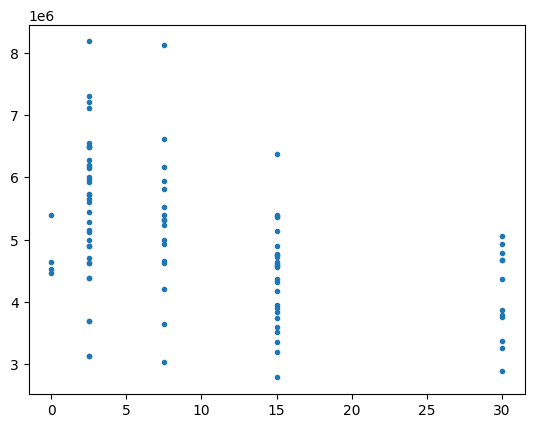

In [ ]:
data['AntiguedadNum']=data['Antiguedad'].replace({'Entre 0 y 5 años':2.5, 'Remodelado':0, 'Entre 10 y 20 años':15,
       'Entre 5 y 10 años':7.5, 'Más de 20 años':30})
plt.plot(data['AntiguedadNum'], data['ValorPorMetroCuadrado'],'.')

In [ ]:
#miremos nuevamente los datos que tenemos...
data.head()

,Cod_Inmueble,Barrio,Precio,Antiguedad,Area_Construida,Area_Privada,Valor_Admon,Parqueaderos,Habitaciones,Baños,Estrato,ValorPorMetroCuadrado,AntiguedadNum
0,11318-M3058418,Poblado,518000000,Entre 0 y 5 años,110.0,122.0,377000.0,1,4,3,6.0,4.709091e+06,2.5
1,11318-M3021864,Belén,382000000,Entre 0 y 5 años,64.0,64.0,190000.0,1,2,3,5.0,5.968750e+06,2.5
2,11318-M3058231,Laureles,845000000,Entre 0 y 5 años,137.0,137.0,530000.0,2,3,4,5.0,6.167883e+06,2.5
3,13155-M3070155,Poblado,705000000,Entre 0 y 5 años,123.0,123.0,600000.0,2,3,2,6.0,5.731707e+06,2.5
4,2364-M3070004,Poblado,1250000000,Remodelado,232.0,232.0,680000.0,2,3,5,6.0,5.387931e+06,0.0


In [ ]:
data.groupby(by=['Barrio','Estrato']).agg({'ValorPorMetroCuadrado':'mean'})

ValorPorMetroCuadrado
Barrio         Estrato                       
Belén          4.0               3.650794e+06
               5.0               5.166667e+06
Calasanz       5.0               3.846154e+06
Centro         4.0               3.258427e+06
Conquistadores 4.0               4.900000e+06
               5.0               5.171920e+06
La América     3.0               5.000000e+06
Laureles       5.0               5.169251e+06
               6.0               4.900000e+06
Los Colores    3.0               4.776119e+06
Medellín       6.0               3.793103e+06
Poblado        4.0               4.154978e+06
               5.0               4.772758e+06
               6.0               5.176178e+06
Robledo        1.0               3.200000e+06
               4.0               4.788126e+06
Sabaneta       5.0               3.698387e+06

In [ ]:
#Creemos una tabla que nos calcule el valor promedio de las viviendas de acuerdo con el barrio y la antigüedad.
#Para esto supondremos una filas dadas por el barrio y unas columnas dadas por el valor de la antigüedad.
#pt=pd.pivot_table(data, index=['Barrio', 'Estrato'], columns=['Antiguedad', 'Baños'], values='ValorPorMetroCuadrado', aggfunc='mean').fillna(0)
pt=pd.pivot_table(data, index=['Barrio','Antiguedad'], columns=['Estrato'], values='ValorPorMetroCuadrado',
                  aggfunc='mean').fillna(0)
pt=pt.astype(int)

pt

Estrato                                1.0      3.0      4.0      5.0      6.0
Barrio         Antiguedad                                                     
Belén          Entre 0 y 5 años          0        0        0  5484375        0
               Entre 5 y 10 años         0        0  3650793        0        0
               Remodelado                0        0        0  4531250        0
Calasanz       Entre 10 y 20 años        0        0        0  3846153        0
Centro         Más de 20 años            0        0  3258426        0        0
Conquistadores Entre 0 y 5 años          0        0        0  5597938        0
               Entre 10 y 20 años        0        0  4900000  4745901        0
La América     Entre 5 y 10 años         0  5000000        0        0        0
Laureles       Entre 0 y 5 años          0        0        0  5316392  4900000
               Entre 10 y 20 años        0        0        0  5245238        0
               Más de 20 años            0        0        0  4725408        0
Los Colores    Entre 10 y 20 años        0  4776119        0        0        0
Medellín       Más de 20 años            0        0        0        0  3793103
Poblado        Entre 0 y 5 años          0        0        0  5147058  5847734
               Entre 10 y 20 años        0        0        0        0  4367112
               Entre 5 y 10 años         0        0  4933333  4864184  5647979
               Más de 20 años            0        0  3376623  4468671  4120510
               Remodelado                0        0        0  4640921  5387931
Robledo        Entre 0 y 5 años          0        0  5118421        0        0
               Entre 10 y 20 años  3200000        0        0        0        0
               Remodelado                0        0  4457831        0        0
Sabaneta       Entre 0 y 5 años          0        0        0  3698387        0

In [ ]:
#Y como seguro usted ya lo ha pensado... se pueden hacer agrupaciones utilizando listas para el índice o listas para los valores o las columnas.
pt=pd.pivot_table(data=data, index=['Barrio','Estrato'], columns=['Antiguedad'], values='ValorPorMetroCuadrado', aggfunc='mean')
pt=pt.fillna(0)
#pt=pt/1e6 #Llevemos los valores a millones.
pt=pt.astype(int)
pt.map("${:,.0f}".format)

Antiguedad             Entre 0 y 5 años Entre 10 y 20 años Entre 5 y 10 años  \
Barrio         Estrato                                                         
Belén          4.0                $0.00              $0.00     $3,650,793.00   
               5.0        $5,484,375.00              $0.00             $0.00   
Calasanz       5.0                $0.00      $3,846,153.00             $0.00   
Centro         4.0                $0.00              $0.00             $0.00   
Conquistadores 4.0                $0.00      $4,900,000.00             $0.00   
               5.0        $5,597,938.00      $4,745,901.00             $0.00   
La América     3.0                $0.00              $0.00     $5,000,000.00   
Laureles       5.0        $5,316,392.00      $5,245,238.00             $0.00   
               6.0        $4,900,000.00              $0.00             $0.00   
Los Colores    3.0                $0.00      $4,776,119.00             $0.00   
Medellín       6.0                $0.00              $0.00             $0.00   
Poblado        4.0                $0.00              $0.00     $4,933,333.00   
               5.0        $5,147,058.00              $0.00     $4,864,184.00   
               6.0        $5,847,734.00      $4,367,112.00     $5,647,979.00   
Robledo        1.0                $0.00      $3,200,000.00             $0.00   
               4.0        $5,118,421.00              $0.00             $0.00   
Sabaneta       5.0        $3,698,387.00              $0.00             $0.00   

Antiguedad             Más de 20 años     Remodelado  
Barrio         Estrato                                
Belén          4.0              $0.00          $0.00  
               5.0              $0.00  $4,531,250.00  
Calasanz       5.0              $0.00          $0.00  
Centro         4.0      $3,258,426.00          $0.00  
Conquistadores 4.0              $0.00          $0.00  
               5.0              $0.00          $0.00  
La América     3.0              $0.00          $0.00  
Laureles       5.0      $4,725,408.00          $0.00  
               6.0              $0.00          $0.00  
Los Colores    3.0              $0.00          $0.00  
Medellín       6.0      $3,793,103.00          $0.00  
Poblado        4.0      $3,376,623.00          $0.00  
               5.0      $4,468,671.00  $4,640,921.00  
               6.0      $4,120,510.00  $5,387,931.00  
Robledo        1.0              $0.00          $0.00  
               4.0              $0.00  $4,457,831.00  
Sabaneta       5.0              $0.00          $0.00